In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [208]:
def combine_prices_data(prices_df_list):
    """
    For a list of days, price DataFrames, and trade DataFrames, 
    shift the timestamps of each day's price and trade data so that the temporal sequence
    for each product can be aligned and concatenated.
    Returns a tuple of two concatenated DataFrames (prices, trades) across all periods for each product.
    """
    shifted_price_dfs = []
    last_timestamp_price = 0

    for i, prices_df in enumerate(prices_df_list):
        # Prices
        p_df = prices_df.copy()
        if i == 0 or p_df.empty:
            # Day 1: no shift needed
            p_df['timestamp'] = p_df['timestamp']
        else:
            # Shift subsequent days so that they follow the previous one
            p_df['timestamp'] = p_df['timestamp'] + last_timestamp_price + 100
        shifted_price_dfs.append(p_df)
        if not p_df.empty:
            last_timestamp_price = p_df['timestamp'].iloc[-1]

    combined_prices_df = pd.concat(shifted_price_dfs, axis=0, ignore_index=True)
    return combined_prices_df

def combine_trades_data(trades_df_list):
    """
    For a list of trade DataFrames, 
    shift the timestamps of each day's trade data so that the temporal sequence
    for each product can be aligned and concatenated.
    Returns a concatenated DataFrame across all periods for each product.
    """

    shifted_trade_dfs = []
    last_timestamp_trade = 0

    for i, trades_df in enumerate(trades_df_list):
        t_df = trades_df.copy()
        if i == 0 or t_df.empty:
            t_df['timestamp'] = t_df['timestamp']
        else:
            t_df['timestamp'] = t_df['timestamp'] + last_timestamp_trade + 100
        shifted_trade_dfs.append(t_df)
        if not t_df.empty:
            last_timestamp_trade = t_df['timestamp'].iloc[-1]

    combined_trades_df = pd.concat(shifted_trade_dfs, axis=0, ignore_index=True)
    return combined_trades_df



In [209]:
prices_day_1_df = pd.read_csv('prices_round_3_day_0.csv', sep=';')
prices_day_2_df = pd.read_csv('prices_round_3_day_1.csv', sep=';')
prices_day_3_df = pd.read_csv('prices_round_3_day_2.csv', sep=';')

trades_day_1_df = pd.read_csv('trades_round_3_day_0.csv', sep=';')
trades_day_2_df = pd.read_csv('trades_round_3_day_1.csv', sep=';')
trades_day_3_df = pd.read_csv('trades_round_3_day_2.csv', sep=';')


In [210]:
prices_day_1_df


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,0,999900,VEV_5100,162,23,NaN,NaN,NaN,NaN,166,10,167.0,13.0,NaN,NaN,164.0,0.0
119996,0,999900,VEV_6000,0,21,NaN,NaN,NaN,NaN,1,21,NaN,NaN,NaN,NaN,0.5,0.0
119997,0,999900,HYDROGEL_PACK,9950,12,9947.0,21.0,NaN,NaN,9966,12,9968.0,21.0,NaN,NaN,9958.0,0.0
119998,0,999900,VELVETFRUIT_EXTRACT,5241,69,NaN,NaN,NaN,NaN,5247,69,NaN,NaN,NaN,NaN,5244.0,0.0


In [211]:
trades_day_1_df

,timestamp,buyer,seller,symbol,currency,price,quantity
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3
...,...,...,...,...,...,...,...
1303,997000,NaN,NaN,HYDROGEL_PACK,XIRECS,9977.0,5
1304,997200,NaN,NaN,VEV_4000,XIRECS,1255.0,3
1305,997900,NaN,NaN,VEV_4000,XIRECS,1255.0,2
1306,999000,NaN,NaN,VEV_4000,XIRECS,1253.0,1


In [212]:
print("Prices Keys:")
print(prices_day_1_df.keys())
print()

print("Trades Keys:")
print(trades_day_1_df.keys())
print()


Prices Keys:
Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')

Trades Keys:
Index(['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price',
       'quantity'],
      dtype='object')



## HYDROGEL PACK

In [213]:
hydrogelpack_prices_day_1_df = prices_day_1_df[prices_day_1_df['product'] == 'HYDROGEL_PACK']
hydrogelpack_trades_day_1_df = trades_day_1_df[trades_day_1_df['symbol'] == 'HYDROGEL_PACK']
hydrogelpack_prices_day_2_df = prices_day_2_df[prices_day_2_df['product'] == 'HYDROGEL_PACK']
hydrogelpack_trades_day_2_df = trades_day_2_df[trades_day_2_df['symbol'] == 'HYDROGEL_PACK']
hydrogelpack_prices_day_3_df = prices_day_3_df[prices_day_3_df['product'] == 'HYDROGEL_PACK']
hydrogelpack_trades_day_3_df = trades_day_3_df[trades_day_3_df['symbol'] == 'HYDROGEL_PACK']

hydrogelpack_prices_day_1_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
7,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0
19,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0
24,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0
41,0,300,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,23.0,NaN,NaN,10002.0,0.0
54,0,400,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,23.0,NaN,NaN,10003.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119949,0,999500,HYDROGEL_PACK,9951,13,9949.0,28.0,NaN,NaN,9967,13,9970.0,28.0,NaN,NaN,9959.0,0.0
119955,0,999600,HYDROGEL_PACK,9952,14,9949.0,27.0,NaN,NaN,9968,14,9970.0,27.0,NaN,NaN,9960.0,0.0
119964,0,999700,HYDROGEL_PACK,9948,11,9946.0,24.0,NaN,NaN,9964,11,9966.0,24.0,NaN,NaN,9956.0,0.0
119983,0,999800,HYDROGEL_PACK,9950,10,9948.0,27.0,NaN,NaN,9966,10,9968.0,27.0,NaN,NaN,9958.0,0.0


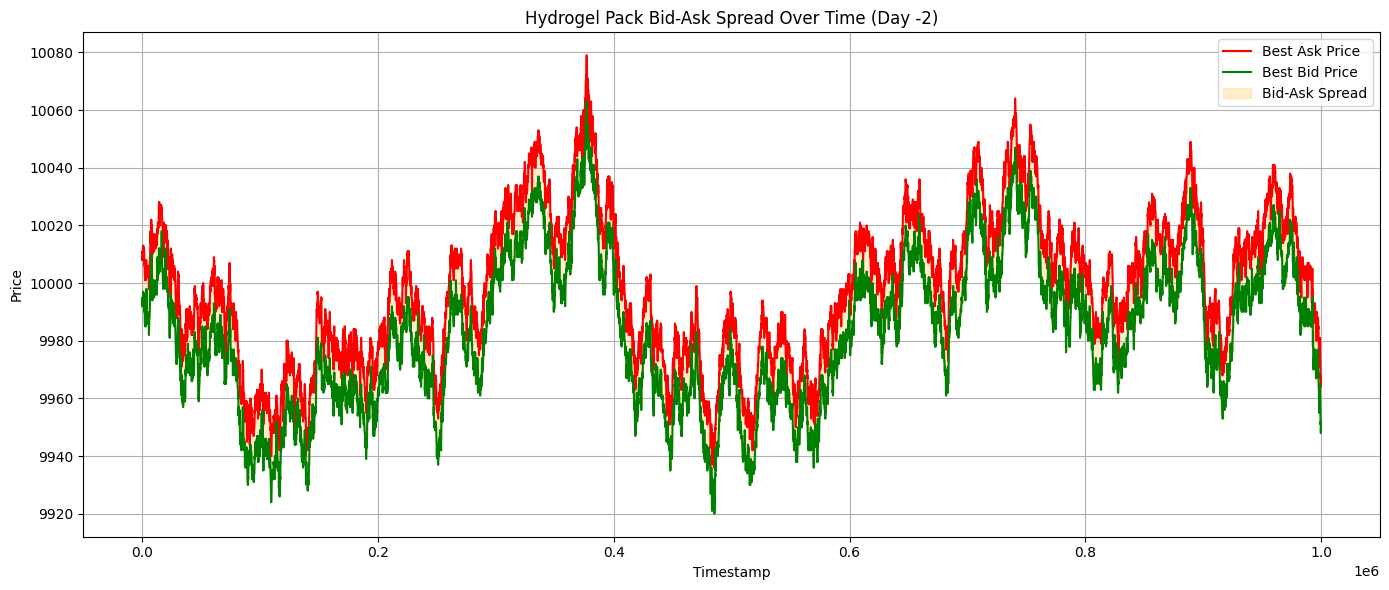

In [214]:
plt.figure(figsize=(14, 6))
plt.plot(hydrogelpack_prices_day_1_df['timestamp'], hydrogelpack_prices_day_1_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(hydrogelpack_prices_day_1_df['timestamp'], hydrogelpack_prices_day_1_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    hydrogelpack_prices_day_1_df['timestamp'],
    hydrogelpack_prices_day_1_df['bid_price_1'],
    hydrogelpack_prices_day_1_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("Hydrogel Pack Bid-Ask Spread Over Time (Day -2)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


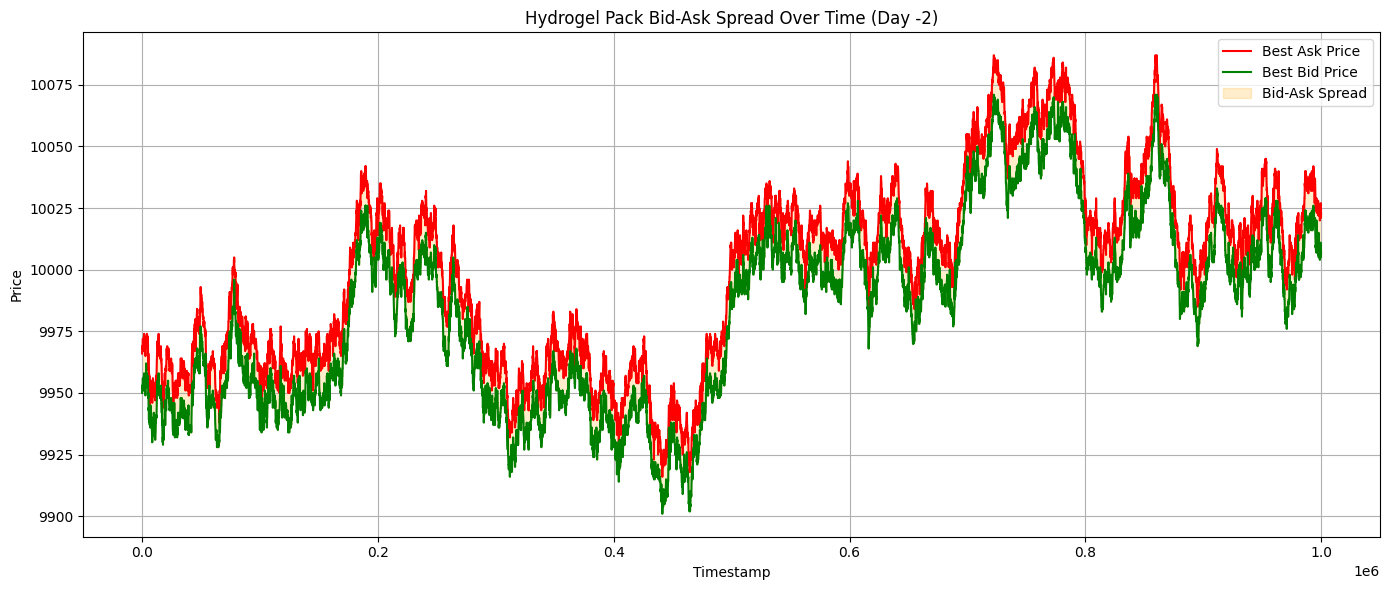

In [215]:
plt.figure(figsize=(14, 6))
plt.plot(hydrogelpack_prices_day_2_df['timestamp'], hydrogelpack_prices_day_2_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(hydrogelpack_prices_day_2_df['timestamp'], hydrogelpack_prices_day_2_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    hydrogelpack_prices_day_2_df['timestamp'],
    hydrogelpack_prices_day_2_df['bid_price_1'],
    hydrogelpack_prices_day_2_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("Hydrogel Pack Bid-Ask Spread Over Time (Day -2)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


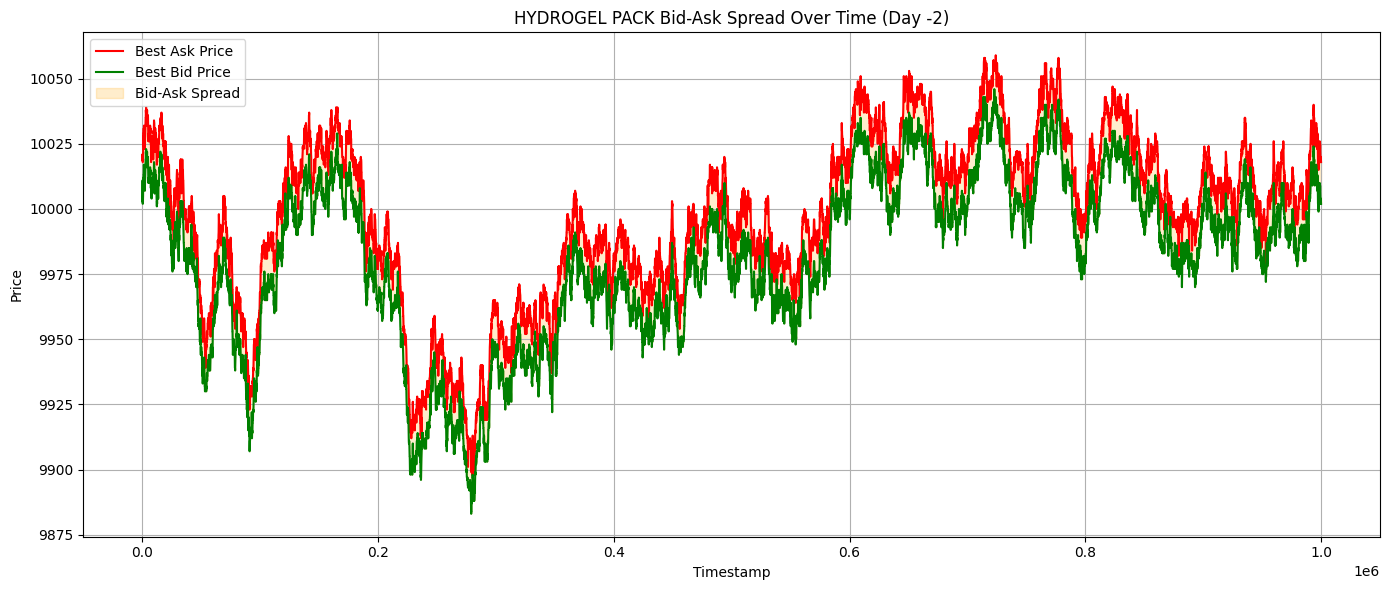

In [216]:
plt.figure(figsize=(14, 6))
plt.plot(hydrogelpack_prices_day_3_df['timestamp'], hydrogelpack_prices_day_3_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(hydrogelpack_prices_day_3_df['timestamp'], hydrogelpack_prices_day_3_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    hydrogelpack_prices_day_3_df['timestamp'],
    hydrogelpack_prices_day_3_df['bid_price_1'],
    hydrogelpack_prices_day_3_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("HYDROGEL PACK Bid-Ask Spread Over Time (Day -2)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [217]:
# Combine OSMIUM Day 1, 2, and 3 price data into one dataframe, aligning timestamps for continuity.
hydrogelpack_combined_df = combine_prices_data([hydrogelpack_prices_day_1_df, hydrogelpack_prices_day_2_df, hydrogelpack_prices_day_3_df])


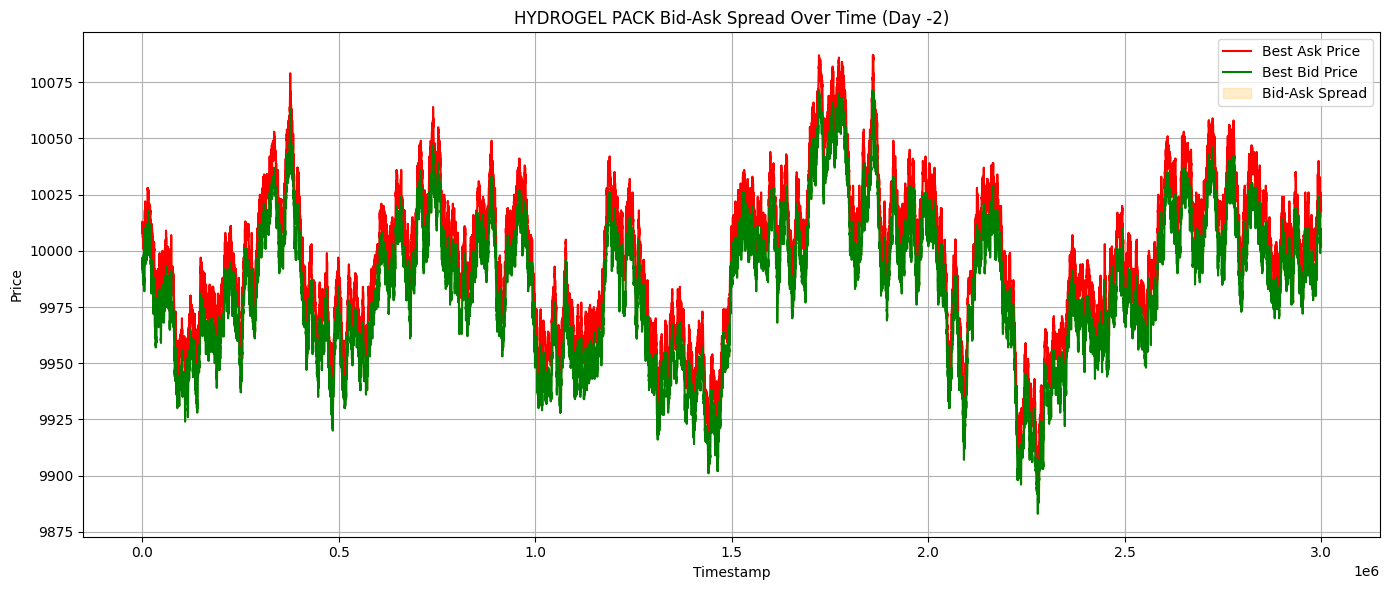

In [218]:
plt.figure(figsize=(14, 6))
plt.plot(hydrogelpack_combined_df['timestamp'], hydrogelpack_combined_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(hydrogelpack_combined_df['timestamp'], hydrogelpack_combined_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    hydrogelpack_combined_df['timestamp'],
    hydrogelpack_combined_df['bid_price_1'],
    hydrogelpack_combined_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("HYDROGEL PACK Bid-Ask Spread Over Time (Day -2)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## VELVEFRUIT EXTRACT

In [219]:
# 1. Prepare Pepper Root: Shift Day 2 and Day 3 so their timestamps continue after Day 1
velvefruitextract_prices_day_1_df = prices_day_1_df[prices_day_1_df['product'] == 'VELVETFRUIT_EXTRACT'].copy()
velvefruitextract_prices_day_2_df = prices_day_2_df[prices_day_2_df['product'] == 'VELVETFRUIT_EXTRACT'].copy()
velvefruitextract_prices_day_3_df = prices_day_3_df[prices_day_3_df['product'] == 'VELVETFRUIT_EXTRACT'].copy()

velvefruitextract_prices_day_1_df


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
5,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0
13,0,100,VELVETFRUIT_EXTRACT,5248,69,NaN,NaN,NaN,NaN,5253,23,5254.0,46.0,NaN,NaN,5250.5,0.0
25,0,200,VELVETFRUIT_EXTRACT,5248,20,5247.0,40.0,NaN,NaN,5253,60,NaN,NaN,NaN,NaN,5250.5,0.0
47,0,300,VELVETFRUIT_EXTRACT,5248,24,5247.0,40.0,NaN,NaN,5253,64,NaN,NaN,NaN,NaN,5250.5,0.0
55,0,400,VELVETFRUIT_EXTRACT,5248,25,5247.0,37.0,NaN,NaN,5253,62,NaN,NaN,NaN,NaN,5250.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119951,0,999500,VELVETFRUIT_EXTRACT,5242,63,NaN,NaN,NaN,NaN,5247,19,5248.0,44.0,NaN,NaN,5244.5,0.0
119962,0,999600,VELVETFRUIT_EXTRACT,5243,56,NaN,NaN,NaN,NaN,5245,11,5248.0,25.0,5249.0,31.0,5244.0,0.0
119965,0,999700,VELVETFRUIT_EXTRACT,5243,20,5242.0,37.0,NaN,NaN,5248,57,NaN,NaN,NaN,NaN,5245.5,0.0
119980,0,999800,VELVETFRUIT_EXTRACT,5243,24,5242.0,44.0,NaN,NaN,5248,68,NaN,NaN,NaN,NaN,5245.5,0.0


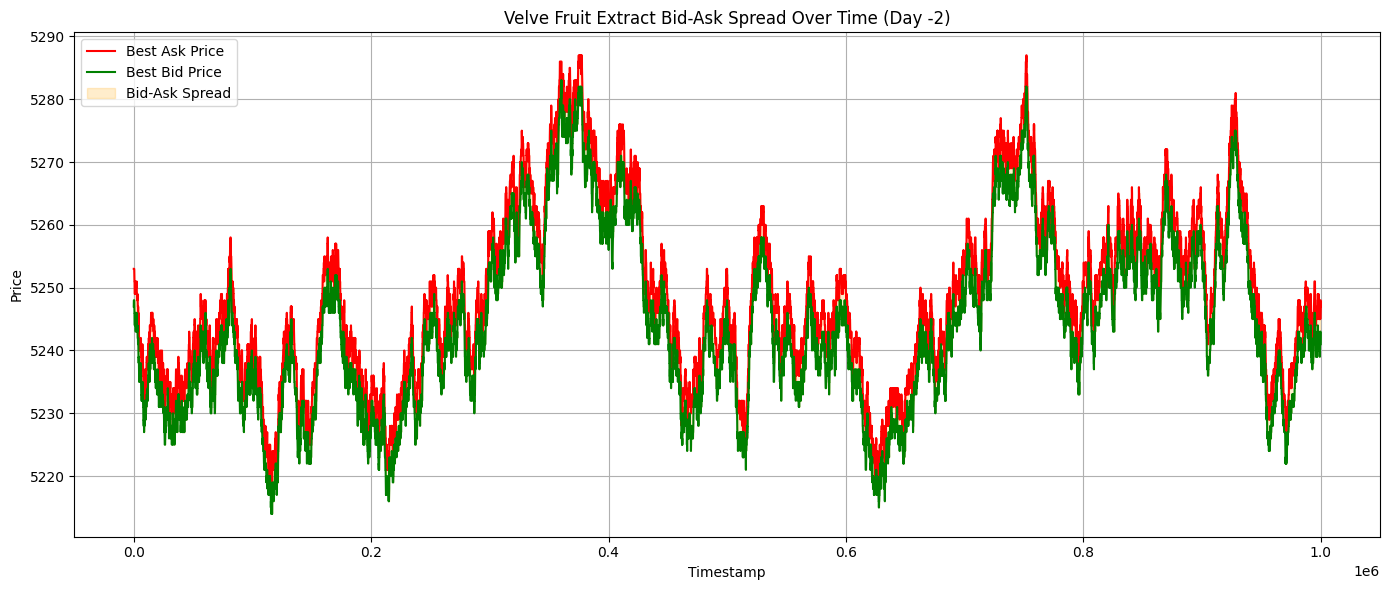

In [220]:

# Plot Pepper Root Bid-Ask Spread Over Time
plt.figure(figsize=(14, 6))
plt.plot(velvefruitextract_prices_day_1_df['timestamp'], velvefruitextract_prices_day_1_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(velvefruitextract_prices_day_1_df['timestamp'], velvefruitextract_prices_day_1_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    velvefruitextract_prices_day_1_df['timestamp'],
    velvefruitextract_prices_day_1_df['bid_price_1'],
    velvefruitextract_prices_day_1_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("Velve Fruit Extract Bid-Ask Spread Over Time (Day -2)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


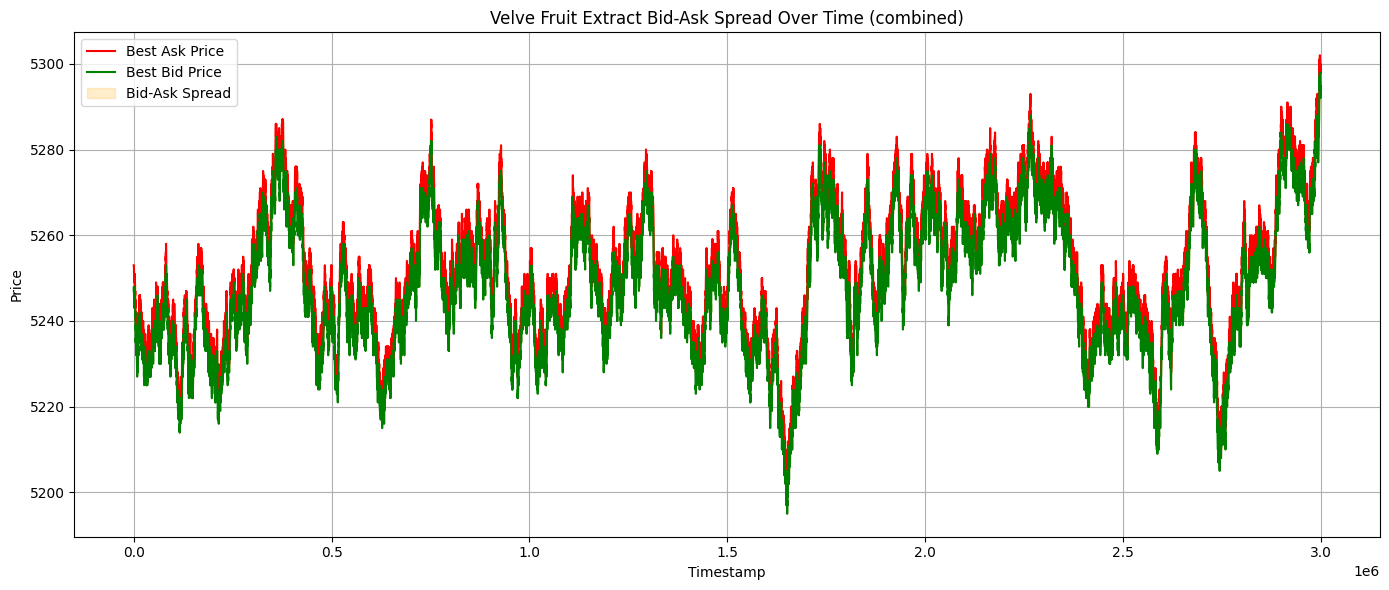

In [221]:
velvefruitextract_combined_df = combine_prices_data([velvefruitextract_prices_day_1_df, velvefruitextract_prices_day_2_df, velvefruitextract_prices_day_3_df])
# Plot Pepper Root Bid-Ask Spread Over Time
plt.figure(figsize=(14, 6))
plt.plot(velvefruitextract_combined_df['timestamp'], velvefruitextract_combined_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(velvefruitextract_combined_df['timestamp'], velvefruitextract_combined_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    velvefruitextract_combined_df['timestamp'],
    velvefruitextract_combined_df['bid_price_1'],
    velvefruitextract_combined_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("Velve Fruit Extract Bid-Ask Spread Over Time (combined)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



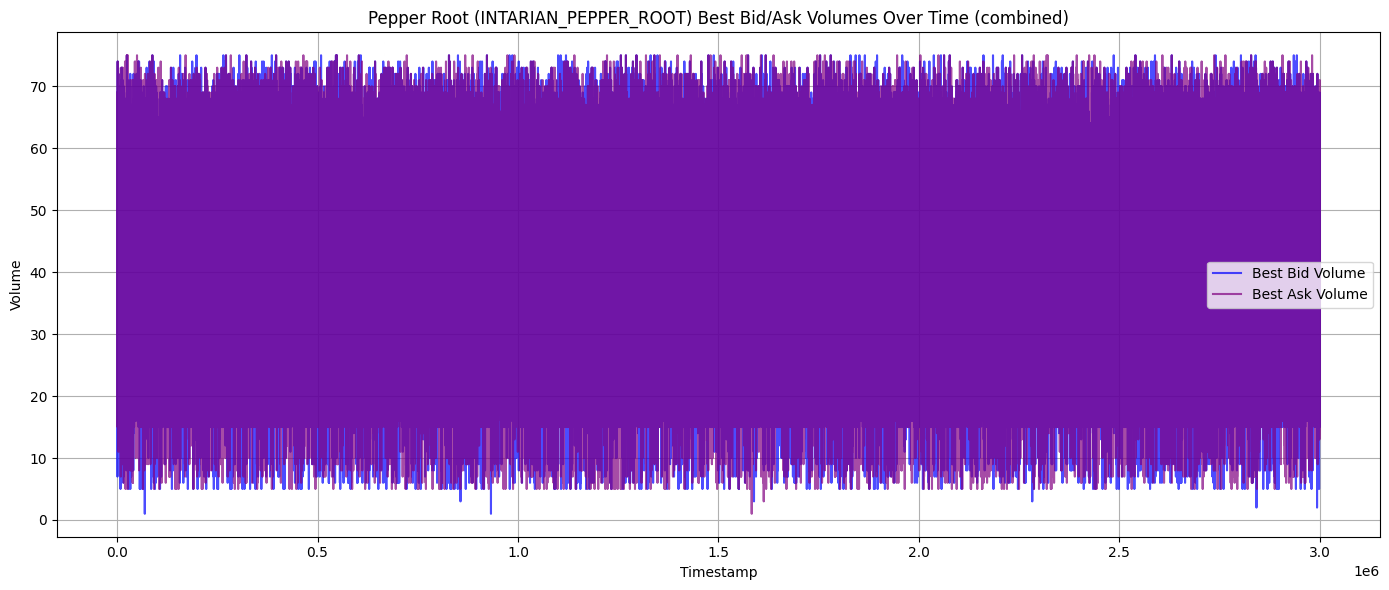

Pepper Root - Best Bid Volume Mean: 37.8253
Pepper Root - Best Ask Volume Mean: 37.80113333333333
Pepper Root - Best Bid Volume Std Dev: 21.016730716479202
Pepper Root - Best Ask Volume Std Dev: 21.05491777157143


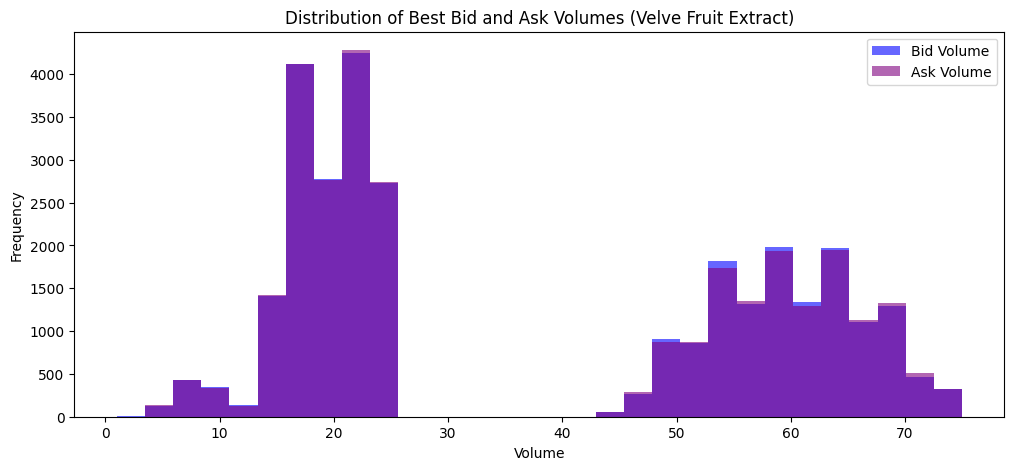

In [222]:
# Analysis of Bid and Ask Volumes for Pepper Root

# Let's look at the evolution of best bid and ask volumes over time
plt.figure(figsize=(14, 6))
plt.plot(
    velvefruitextract_combined_df['timestamp'],
    velvefruitextract_combined_df['bid_volume_1'],
    label='Best Bid Volume',
    color='blue',
    alpha=0.7
)
plt.plot(
    velvefruitextract_combined_df['timestamp'],
    velvefruitextract_combined_df['ask_volume_1'],
    label='Best Ask Volume',
    color='purple',
    alpha=0.7
)
plt.title("Pepper Root (INTARIAN_PEPPER_ROOT) Best Bid/Ask Volumes Over Time (combined)")
plt.xlabel("Timestamp")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Statistical summary
bid_vol_mean = velvefruitextract_combined_df['bid_volume_1'].mean()
ask_vol_mean = velvefruitextract_combined_df['ask_volume_1'].mean()
bid_vol_std = velvefruitextract_combined_df['bid_volume_1'].std()
ask_vol_std = velvefruitextract_combined_df['ask_volume_1'].std()

print("Pepper Root - Best Bid Volume Mean:", bid_vol_mean)
print("Pepper Root - Best Ask Volume Mean:", ask_vol_mean)
print("Pepper Root - Best Bid Volume Std Dev:", bid_vol_std)
print("Pepper Root - Best Ask Volume Std Dev:", ask_vol_std)

# Visualize the distribution of bid and ask volumes
plt.figure(figsize=(12,5))
plt.hist(
    velvefruitextract_combined_df['bid_volume_1'].dropna(),
    bins=30, alpha=0.6, label='Bid Volume', color='blue'
)
plt.hist(
    velvefruitextract_combined_df['ask_volume_1'].dropna(),
    bins=30, alpha=0.6, label='Ask Volume', color='purple'
)
plt.title("Distribution of Best Bid and Ask Volumes (Velve Fruit Extract)")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## OPTIONS

In [223]:
options = [{"name": "VEV_4000", "price": 4000},
{"name": "VEV_4500", "price": 4500},
{"name": "VEV_5000", "price": 5000},
{"name": "VEV_5100", "price": 5100},
{"name": "VEV_5200", "price": 5200},
{"name": "VEV_5300", "price": 5300},
{"name": "VEV_5400", "price": 5400},
{"name": "VEV_5500", "price": 5500},
{"name": "VEV_6000", "price": 6000},
{"name": "VEV_6500", "price": 6500}]

combined_option_prices = []
combined_option_trades = []

for option in options:
    
    option_prices_day_1_df = prices_day_1_df[prices_day_1_df['product'] == option['name']]
    option_prices_day_2_df = prices_day_2_df[prices_day_2_df['product'] == option['name']]
    option_prices_day_3_df = prices_day_3_df[prices_day_3_df['product'] == option['name']]

    combined_option_prices_df = combine_prices_data([option_prices_day_1_df, option_prices_day_2_df, option_prices_day_3_df])

    combined_option_prices.append(combined_option_prices_df)
    
    option_prices_day_1_df = trades_day_1_df[trades_day_1_df['symbol'] == option['name']]
    option_prices_day_2_df = trades_day_2_df[trades_day_2_df['symbol'] == option['name']]
    option_prices_day_3_df = trades_day_3_df[trades_day_3_df['symbol'] == option['name']]

    combined_option_trades_df = combine_trades_data([option_prices_day_1_df, option_prices_day_2_df, option_prices_day_3_df])

    combined_option_trades.append(combined_option_trades_df)


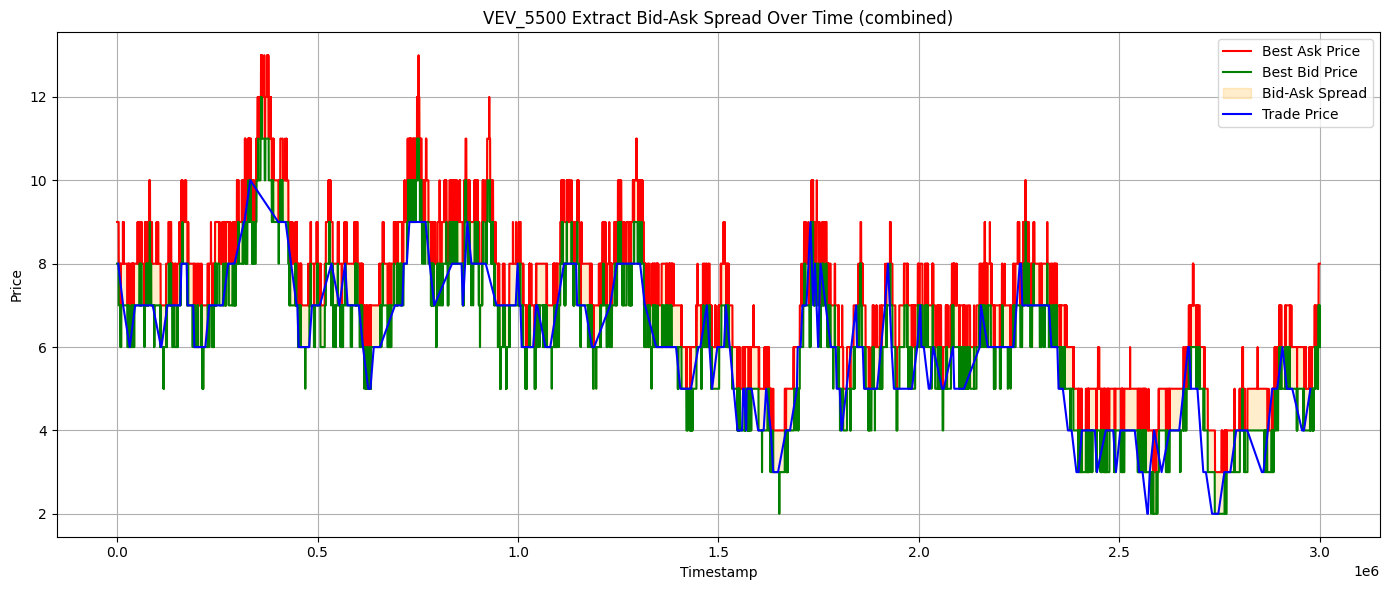

In [241]:
idx = 7

opt = combined_option_prices[idx]

# Plot Pepper Root Bid-Ask Spread Over Time
plt.figure(figsize=(14, 6))
plt.plot(opt['timestamp'], opt['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(opt['timestamp'], opt['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    opt['timestamp'],
    opt['bid_price_1'],
    opt['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.plot(combined_option_trades[idx]['timestamp'], combined_option_trades[idx]['price'], label='Trade Price', color='blue', linewidth=1.5)

plt.title(f"{options[idx]['name']} Extract Bid-Ask Spread Over Time (combined)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Best Window Grid Search

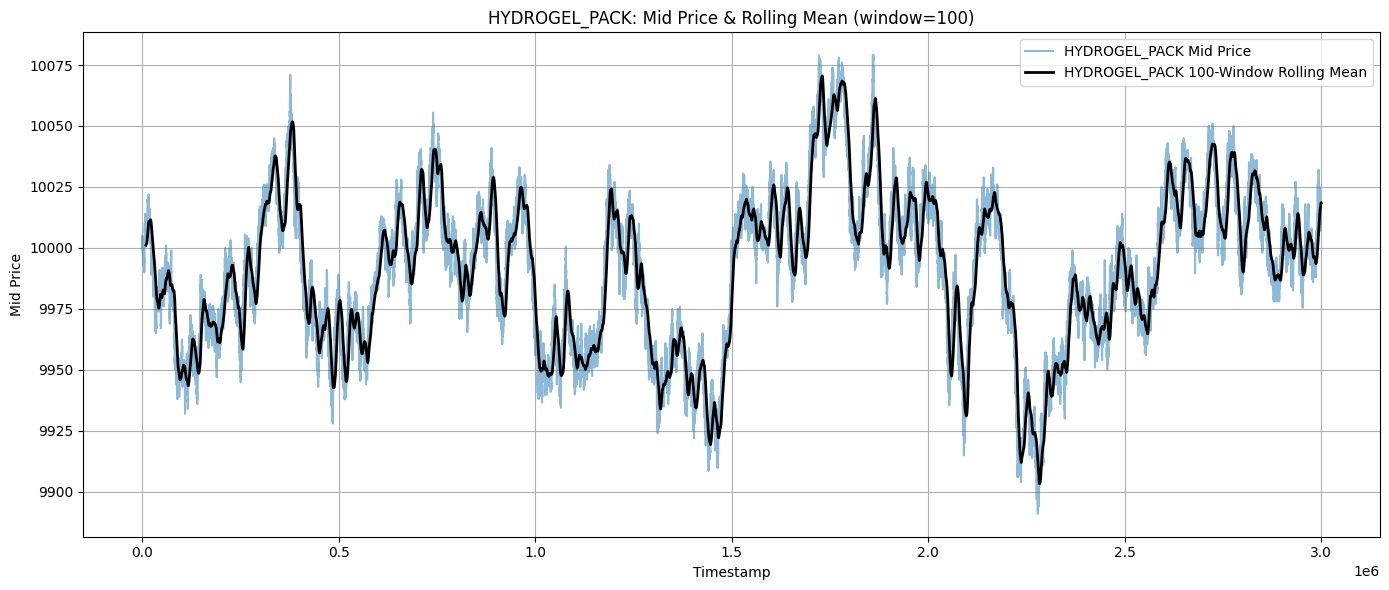

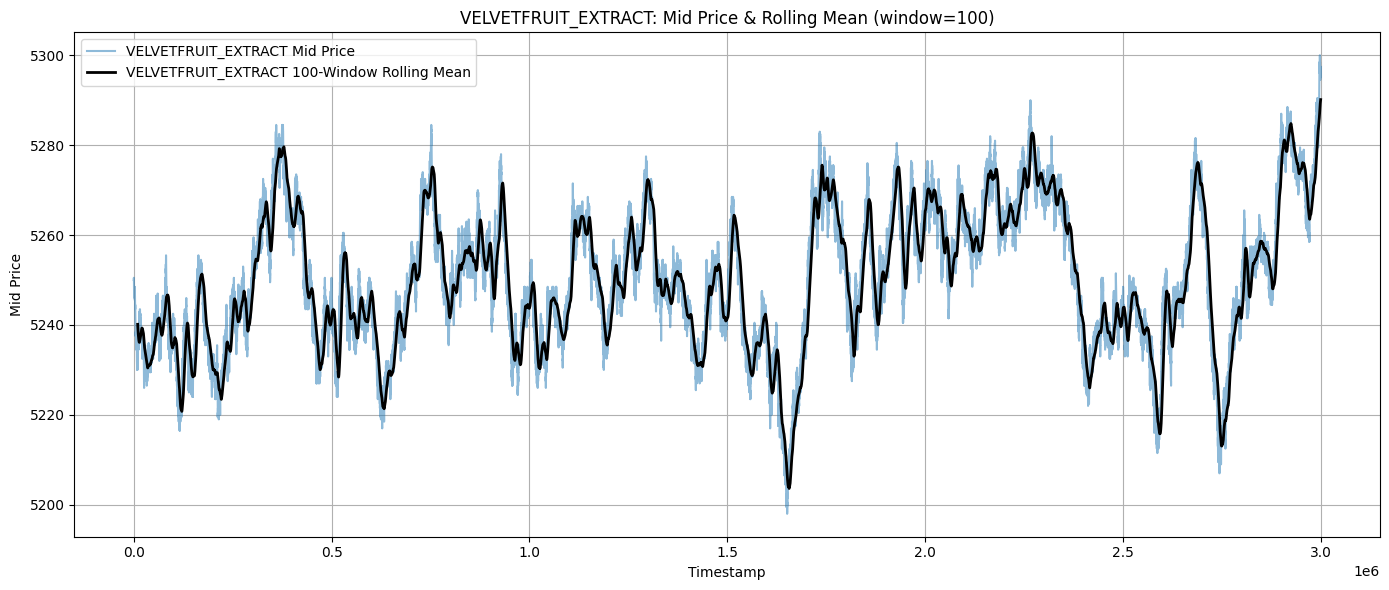

In [225]:
def plot_rolling_mean(df, window, label=None):
    """
    Plots the mid price and its rolling mean for the given dataframe.
    """
    if df.empty:
        print(f"No data to plot for: {label}")
        return
    mid_rolling = df['mid_price'].rolling(window=window).mean()
    plt.figure(figsize=(14, 6))
    plt.plot(df['timestamp'], df['mid_price'], alpha=0.5, label=f'{label} Mid Price')
    plt.plot(df['timestamp'], mid_rolling, color='black', linewidth=2, label=f'{label} {window}-Window Rolling Mean')
    plt.title(f"{label}: Mid Price & Rolling Mean (window={window})")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
lookback_window = 100  # You can change this to set the lookback window

# Plot for HYDROGEL_PACK
plot_rolling_mean(hydrogelpack_combined_df, lookback_window, label='HYDROGEL_PACK')

# Plot for VELVETFRUIT_EXTRACT
plot_rolling_mean(velvefruitextract_combined_df, lookback_window, label='VELVETFRUIT_EXTRACT')

# FULL-SCALE EDA & STRATEGY ANALYSIS

The cells below build on the data already loaded above and add:

1. **Universe overview** — per-product summary stats, depth, spread.
2. **Joint plot** — underlying + all option strikes on one chart with strike lines.
3. **Mean reversion** — AR(1)/half-life/variance-ratio for HYDROGEL_PACK and VELVETFRUIT_EXTRACT.
4. **Realized volatility** — multi-frequency RV to handle microstructure noise.
5. **Black-Scholes implied volatility** — per-strike IV and the volatility smile.
6. **IV-vs-smile dislocation** — per-snapshot residual vs fitted smile (arb signal).
7. **Time value / sub-intrinsic** — cheap-call detection on deep ITM strikes.
8. **Cross-product correlation matrix.**
9. **Trading strategy proposals.**

> **Universe**: `VELVETFRUIT_EXTRACT` (the underlying, ~5250) and `HYDROGEL_PACK` (~9990) are spot products. `VEV_<K>` are European call options on `VELVETFRUIT_EXTRACT` at strike K. Strike grid: 4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500.

> **Time convention assumed**: 10000 timestamps per day → 100 ticks between rows (each row is one tick). Vouchers expire 7 days from start of round 3 (assumption — adjust `TTE_DAYS_AT_START` below if you know otherwise).


In [ ]:
# Build a wide-format DataFrame: one row per global timestamp, one column per product (mid price)
all_prices = pd.concat([
    prices_day_1_df.assign(day=0),
    prices_day_2_df.assign(day=1),
    prices_day_3_df.assign(day=2),
], ignore_index=True)
all_prices['t_global'] = all_prices['day'] * 1_000_000 + all_prices['timestamp']

# Mid-price wide
mid = all_prices.pivot_table(index='t_global', columns='product', values='mid_price', aggfunc='first').sort_index()

# Best bid/ask wide (for arb checks)
ask1 = all_prices.pivot_table(index='t_global', columns='product', values='ask_price_1', aggfunc='first').sort_index()
bid1 = all_prices.pivot_table(index='t_global', columns='product', values='bid_price_1', aggfunc='first').sort_index()
askv = all_prices.pivot_table(index='t_global', columns='product', values='ask_volume_1', aggfunc='first').sort_index()
bidv = all_prices.pivot_table(index='t_global', columns='product', values='bid_volume_1', aggfunc='first').sort_index()

print(f"Wide-format mid shape: {mid.shape}")
print(f"Products: {list(mid.columns)}")
mid.head()


## 1. Universe overview

In [ ]:
# Per-product summary stats
rows = []
for prod in mid.columns:
    sub = all_prices[all_prices['product'] == prod]
    spread = (sub['ask_price_1'] - sub['bid_price_1']).dropna()
    bdepth = sub['bid_volume_1'].fillna(0) + sub['bid_volume_2'].fillna(0) + sub['bid_volume_3'].fillna(0)
    adepth = sub['ask_volume_1'].fillna(0) + sub['ask_volume_2'].fillna(0) + sub['ask_volume_3'].fillna(0)
    rows.append({
        'product': prod,
        'mid_mean': sub['mid_price'].mean(),
        'mid_std': sub['mid_price'].std(),
        'mid_min': sub['mid_price'].min(),
        'mid_max': sub['mid_price'].max(),
        'spread_med': spread.median(),
        'spread_mean': spread.mean(),
        'bid_depth_med': bdepth.median(),
        'ask_depth_med': adepth.median(),
        'level2_pct': (sub['bid_price_2'].notna() | sub['ask_price_2'].notna()).mean() * 100,
    })
summary = pd.DataFrame(rows).set_index('product').round(2)
summary


**Reading the table**
- `VELVETFRUIT_EXTRACT` (underlying) trades ~5250 with median spread = 5 (tight) and very deep book (~60 lots/level).
- `HYDROGEL_PACK` is independent, mid ~9990, spread ~16 (wider, shallower book ~38 lots).
- Deep-ITM calls (`VEV_4000`, `VEV_4500`) trade close to intrinsic value (1250, 750) but with a *wide* spread (~20 ticks). Their book is shallow.
- `VEV_6000` and `VEV_6500` are stuck at mid 0.5 across the whole sample → bid 0 / ask 1, essentially worthless. Avoid.


In [ ]:
# Plot underlying + all option strikes on one figure
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax = axes[0]
ax.plot(mid.index, mid['VELVETFRUIT_EXTRACT'], color='black', linewidth=1.2, label='VELVETFRUIT_EXTRACT (underlying)')
strikes = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
for k in strikes:
    ax.axhline(k, color='gray', linestyle='--', alpha=0.3)
    ax.text(mid.index.max(), k, f' K={k}', va='center', fontsize=8, color='gray')
ax.set_ylabel('Underlying price')
ax.set_title('VELVETFRUIT_EXTRACT vs option strike grid')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
for d in [1_000_000, 2_000_000]:
    ax.axvline(d, color='red', alpha=0.4, linestyle=':')

ax = axes[1]
import matplotlib.cm as cm
colors = cm.viridis(np.linspace(0, 1, len(strikes)))
for k, c in zip(strikes, colors):
    col = f'VEV_{k}'
    if col in mid.columns:
        ax.plot(mid.index, mid[col], color=c, linewidth=0.8, alpha=0.85, label=f'VEV_{k}')
ax.set_yscale('log')
ax.set_ylabel('Option price (log scale)')
ax.set_xlabel('Global timestamp')
ax.set_title('Option mid prices (all strikes)')
ax.legend(ncol=5, fontsize=8); ax.grid(alpha=0.3)
for d in [1_000_000, 2_000_000]:
    ax.axvline(d, color='red', alpha=0.4, linestyle=':')

plt.tight_layout()
plt.show()


## 2. Mean-reversion analysis (HYDROGEL_PACK + VELVETFRUIT_EXTRACT)

For a stationary AR(1) process `(x_t - μ) = φ·(x_{t-1} - μ) + ε`:
- φ = 1 → random walk
- φ < 1 → mean-reverting; half-life = ln(0.5) / ln(φ)

We also compute the **variance ratio** VR(q) = Var(q-step return) / (q · Var(1-step return)). VR < 1 indicates mean reversion at horizon q; VR > 1 indicates trending.


In [ ]:
def ar1_phi(s):
    s = s.dropna() - s.dropna().mean()
    return float((s.iloc[1:].values * s.iloc[:-1].values).sum() / (s.iloc[:-1].values**2).sum())

def half_life(phi):
    return float(np.log(0.5) / np.log(phi)) if 0 < phi < 1 else np.nan

def variance_ratio(s, q):
    s = s.dropna().values
    var1 = np.diff(s).var()
    varq = (s[q:] - s[:-q]).var() / q
    return varq / var1

mr_results = {}
for prod in ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']:
    s = mid[prod].dropna()
    phi = ar1_phi(s)
    hl = half_life(phi)
    print(f"{prod}: μ={s.mean():.2f}, σ={s.std():.2f}, AR(1) φ={phi:.6f}, half-life≈{hl:.0f} ticks")
    print(f"  Variance ratios:", {q: round(variance_ratio(s, q), 3) for q in [2, 5, 10, 50, 100, 500]})
    print()
    mr_results[prod] = {'phi': phi, 'half_life': hl, 'mean': s.mean(), 'std': s.std()}

# Plot HYDROGEL_PACK with z-score bands (best mean-reversion candidate)
hp = mid['HYDROGEL_PACK'].dropna()
window = 2000
roll_mean = hp.rolling(window).mean()
roll_std = hp.rolling(window).std()
z = (hp - roll_mean) / roll_std

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(hp.index, hp, color='black', alpha=0.5, lw=0.7, label='Mid')
axes[0].plot(hp.index, roll_mean, color='blue', label=f'Rolling mean (w={window})')
axes[0].fill_between(hp.index, roll_mean - 2*roll_std, roll_mean + 2*roll_std, color='blue', alpha=0.15, label='±2σ')
axes[0].set_title(f'HYDROGEL_PACK: rolling mean ± 2σ band  (AR(1) φ={mr_results["HYDROGEL_PACK"]["phi"]:.4f}, half-life≈{mr_results["HYDROGEL_PACK"]["half_life"]:.0f})')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(z.index, z, color='purple', lw=0.7); axes[1].axhline(0, color='gray')
axes[1].axhline(2, color='red', linestyle='--'); axes[1].axhline(-2, color='red', linestyle='--')
axes[1].set_ylabel('Z-score'); axes[1].set_title('HYDROGEL_PACK rolling z-score (entry signal at |z|>2)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Realized volatility (underlying)

We compute realized vol at multiple sampling frequencies. Tick-level RV is biased upward by microstructure noise (bid-ask bounce, integer mid jumps); long-horizon RV is the more reliable estimate but uses fewer samples.

Annualization assumes **10000 timestamps per day** and **252 trading days per year**, so 1 row = 1/2,520,000 of a year.


In [ ]:
ANN_TICKS = 10_000 * 252  # ticks per year (rows)

def rv_at(s, n):
    sampled = s.iloc[::n].dropna()
    lr = np.log(sampled / sampled.shift(1)).dropna()
    if len(lr) < 10: return np.nan
    return lr.std() * np.sqrt(ANN_TICKS / n)

rv_table = pd.DataFrame({
    'every_N_ticks': [1, 5, 10, 50, 100, 500, 1000],
})
for prod in ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK']:
    rv_table[f'RV_ann_{prod}'] = [rv_at(mid[prod], n) for n in rv_table['every_N_ticks']]
print(rv_table.round(4).to_string(index=False))
print()
print("=> Tick-level RV is microstructure-noise inflated. Long-horizon RV ~0.20-0.30 is the realistic underlying vol.")

# Realized vol per day (rolling 1 day = 10000 rows)
plt.figure(figsize=(15, 5))
for prod, color in [('VELVETFRUIT_EXTRACT', 'C0'), ('HYDROGEL_PACK', 'C1')]:
    s = mid[prod].dropna()
    sampled = s.iloc[::100]  # use every 100 ticks to avoid microstructure
    lr = np.log(sampled / sampled.shift(1)).dropna()
    rv = lr.rolling(100).std() * np.sqrt(100 * 252)  # 100 samples × 252 days
    plt.plot(rv.index, rv, color=color, label=f'{prod} (every 100 ticks, rolling 100-step RV)')
plt.title('Rolling realized volatility (annualized)')
plt.ylabel('Annualized RV'); plt.xlabel('Global timestamp')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 4. Black-Scholes implied volatility & smile

We invert call prices to implied volatility using Black-Scholes with **r=0** (no funding cost in IMC). Time-to-expiry assumed: 7 days from start of round 3.


In [ ]:
from scipy.stats import norm
from scipy.optimize import brentq

TTE_DAYS_AT_START = 7        # days remaining at t_global=0
TICKS_PER_DAY = 1_000_000    # global ticks per day

def days_remaining(tg):
    return max(TTE_DAYS_AT_START - tg / TICKS_PER_DAY, 1e-6)

def tte_years(tg):
    return days_remaining(tg) / 252.0

def bs_call(S, K, T, sigma):
    if T <= 0 or sigma <= 0: return max(S - K, 0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_iv(C, S, K, T):
    intrinsic = max(S - K, 0)
    if C < intrinsic + 1e-9 or T <= 0: return np.nan
    try:
        return brentq(lambda v: bs_call(S, K, T, v) - C, 1e-6, 5.0, maxiter=100)
    except Exception:
        return np.nan

# IV time series for each strike (use mid prices)
strikes_liquid = [5000, 5100, 5200, 5300, 5400, 5500]
iv_series = {}
sample_step = 50  # subsample for speed
sub_idx = mid.index[::sample_step]
S_series = mid.loc[sub_idx, 'VELVETFRUIT_EXTRACT']
for K in strikes_liquid:
    col = f'VEV_{K}'
    C_series = mid.loc[sub_idx, col]
    ivs = []
    for tg, S, C in zip(sub_idx, S_series.values, C_series.values):
        if pd.isna(S) or pd.isna(C):
            ivs.append(np.nan); continue
        ivs.append(bs_iv(C, S, K, tte_years(tg)))
    iv_series[K] = pd.Series(ivs, index=sub_idx)

iv_df = pd.DataFrame(iv_series)

plt.figure(figsize=(15, 6))
for K in strikes_liquid:
    plt.plot(iv_df.index, iv_df[K], label=f'K={K}', alpha=0.85, lw=0.9)
plt.title(f'Implied volatility per strike (TTE assumes {TTE_DAYS_AT_START}d at start)')
plt.ylabel('Implied vol (annualized)'); plt.xlabel('Global timestamp')
for d in [1_000_000, 2_000_000]:
    plt.axvline(d, color='red', alpha=0.4, linestyle=':')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("Mean IV per strike:")
print(iv_df.mean().round(4))


In [ ]:
# Volatility smile: average IV per strike vs log-moneyness scaled by sqrt(T) (≈ Black-Scholes 'm')
records = []
for K in strikes_liquid:
    s = iv_df[K].dropna()
    # log-moneyness for each timestamp
    S_at = S_series.reindex(s.index)
    T_at = pd.Series([tte_years(tg) for tg in s.index], index=s.index)
    m = (np.log(K / S_at) / np.sqrt(T_at)).dropna()
    iv = s.reindex(m.index)
    records.append({'K': K, 'm': m.mean(), 'iv': iv.mean(), 'iv_std': iv.std()})

smile = pd.DataFrame(records)
print(smile.round(4))

# Fit quadratic smile
A = np.vstack([np.ones(len(smile)), smile['m'].values, smile['m'].values**2]).T
coef, *_ = np.linalg.lstsq(A, smile['iv'].values, rcond=None)
m_grid = np.linspace(smile['m'].min() - 0.05, smile['m'].max() + 0.05, 100)
iv_fit = coef[0] + coef[1]*m_grid + coef[2]*m_grid**2

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(m_grid, iv_fit, 'k--', label=f'Fit: a={coef[0]:.3f}, b={coef[1]:.3f}, c={coef[2]:.3f}')
axes[0].errorbar(smile['m'], smile['iv'], yerr=smile['iv_std'], fmt='o', capsize=4, label='Mean IV ± 1σ')
for _, r in smile.iterrows():
    axes[0].annotate(f"K={int(r['K'])}", (r['m'], r['iv']), textcoords='offset points', xytext=(5, 8))
axes[0].set_xlabel('m = ln(K/S) / √T'); axes[0].set_ylabel('IV')
axes[0].set_title('Volatility smile (parabolic fit)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(smile['K'], smile['iv'], 'o-', linewidth=2)
for _, r in smile.iterrows():
    axes[1].annotate(f"{r['iv']:.3f}", (r['K'], r['iv']), textcoords='offset points', xytext=(0, 10), ha='center')
axes[1].set_xlabel('Strike'); axes[1].set_ylabel('Mean IV')
axes[1].set_title('IV by strike')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nATM IV (m=0): {coef[0]:.4f}")
print(f"\n>>> NOTE: K=5400 sits well below the smile fit. This is the headline statistical-arb opportunity.")


## 5. Per-snapshot smile residuals (the **stat-arb signal**)

For each snapshot we fit a quadratic smile across the liquid strikes (5000–5500), then compute the residual `IV - fitted_IV` per strike. Strikes with a consistently negative residual are *cheap*; positive residuals are *rich*.


In [ ]:
# Per-snapshot smile fit and residuals
sub_idx2 = mid.index[::100]  # ~300 snapshots
per_strike_dev = {k: [] for k in strikes_liquid}
per_strike_dev_ts = []

for tg in sub_idx2:
    S = mid.loc[tg, 'VELVETFRUIT_EXTRACT']
    if pd.isna(S): continue
    T = tte_years(tg)
    pts = []
    for k in strikes_liquid:
        iv = bs_iv(mid.loc[tg, f'VEV_{k}'], S, k, T)
        if not np.isnan(iv):
            pts.append((k, np.log(k / S) / np.sqrt(T), iv))
    if len(pts) < 4: continue
    m_arr = np.array([p[1] for p in pts])
    iv_arr = np.array([p[2] for p in pts])
    Amat = np.vstack([np.ones_like(m_arr), m_arr, m_arr**2]).T
    c, *_ = np.linalg.lstsq(Amat, iv_arr, rcond=None)
    pred = Amat @ c
    snap = {'t_global': tg}
    for (k, _, iv), p in zip(pts, pred):
        per_strike_dev[k].append(iv - p)
        snap[k] = iv - p
    per_strike_dev_ts.append(snap)

dev_df = pd.DataFrame(per_strike_dev_ts).set_index('t_global')

print("Smile residual stats by strike:")
print("(positive = rich vs smile, negative = cheap vs smile)")
print()
for k in strikes_liquid:
    devs = np.array(per_strike_dev[k])
    print(f"  K={k}: mean_dev={devs.mean():+.4f}  median={np.median(devs):+.4f}  std={devs.std():.4f}  N={len(devs)}")

# Plot residuals over time
plt.figure(figsize=(15, 6))
for k in strikes_liquid:
    plt.plot(dev_df.index, dev_df[k], label=f'K={k}', alpha=0.85, lw=0.9)
plt.axhline(0, color='black', lw=0.5)
plt.title('IV residual vs per-snapshot smile fit  (negative = cheap, positive = rich)')
plt.ylabel('IV − fitted_IV'); plt.xlabel('Global timestamp')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 6. Sub-intrinsic mid prices (deep-ITM check)

A call mid below `S - K` indicates either: (a) wide spread asymmetry around fair value, or (b) a true arbitrage if the *ask* is below intrinsic. We separately check both.


In [ ]:
arb_rows = []
for K in strikes:
    col = f'VEV_{K}'
    if col not in mid.columns: continue
    df = pd.DataFrame({
        'opt_mid': mid[col], 'opt_ask': ask1[col], 'opt_bid': bid1[col],
        'opt_ask_v': askv[col], 'opt_bid_v': bidv[col],
        'S_mid': mid['VELVETFRUIT_EXTRACT'], 'S_bid': bid1['VELVETFRUIT_EXTRACT'], 'S_ask': ask1['VELVETFRUIT_EXTRACT'],
    }).dropna()
    intrinsic = (df['S_mid'] - K).clip(lower=0)
    tv_mid = df['opt_mid'] - intrinsic
    arb_b = df['S_bid'] - K - df['opt_ask']  # buy call ask, sell underlying bid → instantly ITM at expiry
    arb_rows.append({
        'strike': K,
        'mid<intrinsic_pct': float((tv_mid < 0).mean() * 100),
        'mid_TV_mean': tv_mid.mean(),
        'mid_TV_min': tv_mid.min(),
        'ask<intrinsic_n': int((arb_b > 0).sum()),
        'ask<intrinsic_max_edge': arb_b[arb_b > 0].max() if (arb_b > 0).any() else 0,
    })
arb = pd.DataFrame(arb_rows).set_index('strike').round(2)
print(arb)


## 7. Cross-product correlation

Are the products independent or do they move together? We compute correlation on first-differences (informative for execution risk and basket trades).


In [ ]:
# Correlation on level changes (first diff of mid)
liquid_cols = ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500']
diffs = mid[liquid_cols].diff().dropna()
corr = diffs.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, vmin=-1, vmax=1)
plt.title('First-difference correlation matrix (mid prices)')
plt.tight_layout(); plt.show()


## 8. Strategy proposals

Concrete signals derived from the analyses above. Listed in rough order of edge × certainty.

---

### Strategy A — VEV_5400 vs Smile (long vol-arb butterfly)  ★ flagship

**Signal.** VEV_5400 IV trades **~1.0–1.2 vol-points BELOW** the per-snapshot quadratic smile fit, with high persistence (median residual ≈ −0.012 across 300 snapshots, σ ≈ 0.003). Neighboring strikes (5300, 5500) trade **rich** by ~+0.005 each.

**Trade.** **Long the 5300/5400/5500 butterfly**: +1 VEV_5300, −2 VEV_5400, +1 VEV_5500 ⇒ flip signs to *capture* the cheapness at 5400: 
- **Long VEV_5400, short equal-notional VEV_5300 + VEV_5500** (a short fly).

**Mechanics.** Per fly unit: short 1× VEV_5300, long 2× VEV_5400, short 1× VEV_5500. Pay-off is concave around K=5400, max payoff at expiry if S_T = 5400.

**Hedging.** Net delta of the butterfly is ~0 (by construction near ATM); hedge residual delta with the underlying. Re-hedge daily.

**Sizing.** Position limits per voucher will cap the size; trade as many flies as the smallest-leg limit allows.

**Why it should work.** Smile shape is structural; the residual at K=5400 has σ/μ ≈ 0.3 (very stable) and persists across all three days. As IV converges back toward smile, the long-fly P&L is positive.

---

### Strategy B — HYDROGEL_PACK mean reversion  ★ standalone

**Signal.** AR(1) φ ≈ 0.998, half-life ≈ 300 ticks. Variance ratio at q=500 is 0.43 (well below 1) → strong mean-reversion at multi-hundred-tick horizons. μ ≈ 9990, σ ≈ 32.

**Trade.** Rolling z-score around mid-price with window ≈ 1500–2500 ticks. Enter long at z < −2, short at z > +2, exit at |z| < 0.5 or after 500 ticks.

**Risk.** Position limit will be ~30–50 lots. Pure mean-reversion: no underlying-correlation hedge needed (correlation with VELVETFRUIT_EXTRACT ≈ 0).

**Note.** Combine with passive market-making at ±half-spread (median spread = 16) to capture the spread on top of the reversion edge.

---

### Strategy C — VELVETFRUIT_EXTRACT market making

**Signal.** Median spread = 5, deep book (~60 lots/level), AR(1) φ ≈ 0.998, half-life similar to HYDROGEL. Range-bound ±50 around 5250 across all three days.

**Trade.** Quote at best bid + 0 / best ask + 0 (or improve by 1 tick if spread > 5). Skew quotes against current inventory. Tight inventory bands because this is the underlying for the hedge of strategy A.

**Caveat.** This is the underlying you're hedging the option book with. Run market-making P&L net of hedging activity — the MM fills *are* your hedge fills, so the hedge is essentially free.

---

### Strategy D — VEV_4000/VEV_4500 deep-ITM intrinsic-snap

**Signal.** Mids of VEV_4000/4500 trade *below* intrinsic value 10% / 29% of the time (because their spread is wide ~20 around the intrinsic). The *ask* almost never goes below intrinsic, so true riskless arb is rare — but the BID-INTRINSIC and INTRINSIC-MID gaps mean **passive ladder orders** can pick up edge.

**Trade.** Place passive bids slightly below intrinsic on the call (say `intrinsic − 4`) and passive asks above (`intrinsic + 4`), with simultaneous opposite quotes on the underlying. Effectively, market-make the **delta-1 synthetic** = `call − (S − K)`.

**Why.** These deep-ITM calls have delta ≈ 1 and tiny gamma. They're a noisy proxy for the underlying with a wide spread you can capture.

---

### Strategy E — VEV_6000 / VEV_6500 (DON'T trade)

Mid stuck at 0.5 (bid 0 / ask 1) for the entire sample. Probability of expiring ITM is essentially zero (would need a +13–24% move from current spot in 4–7 days, vs realized vol of ~25% annualized = ~0.5% per day). Lifting the ask = burning capital.

---

### Strategy F — Volatility level (sell vol or buy vol?)

**Implied vol** ≈ 0.21 ATM. **Realized vol** at long sampling frequencies (every 500–1000 ticks) ≈ 0.20–0.27. They're roughly in balance. **Don't take a directional vol bet** — focus on the relative value play (Strategy A) which has higher signal-to-noise.

If the round runs longer than expected (more days remaining than the assumed 7), realized variance will accumulate and IV is too low → buy vol. If shorter, sell vol. Calibrate by checking the IV time series in cell §4 — it should drift down each day if TTE is decreasing.

---

### Implementation sketch

```python
# Per tick, in your trader.run():
# 1. Compute current S, T, IVs at strikes 5000-5500.
# 2. Fit quadratic smile a + b*m + c*m^2 with m = ln(K/S)/sqrt(T).
# 3. For each strike K: residual = IV(K) - fit(m_K). Theo price = bs_call(S, K, T, fit(m_K)).
# 4. If theo > ask + ε → buy. If theo < bid − ε → sell.
# 5. Net delta = sum(positions * BS_delta). Hedge with VELVETFRUIT_EXTRACT.
# 6. Independently: HYDROGEL_PACK z-score mean-reversion with rolling 2000-tick window.
```
